# Productivity, taxation, inequality, and poverty

This notebook tests the social-media claim:

> "Productivity growth, not taxation, has been the most proven way to fix inequality and poverty."

The chart in the post is not automatically false. Across countries, higher GDP per capita is strongly associated with lower extreme poverty.  
The problem is the interpretation.

We test four statements separately:

1. **GDP per capita is associated with lower extreme poverty.**
2. **GDP per capita alone explains inequality.**
3. **Taxes and transfers do not matter.**
4. **Productivity growth automatically reaches typical workers.**

The expected result is more nuanced:

> Growth matters for poverty reduction, but it does not settle distribution.  
> Taxes, transfers, labour institutions, public services, and bargaining power shape who receives the gains.

All data are downloaded from public sources when the notebook runs.

## Data sources

The notebook uses:

- **Our World in Data / World Bank PIP**: extreme poverty share.
- **Our World in Data / Eurostat, OECD, IMF, World Bank**: GDP per capita.
- **Our World in Data / World Bank PIP**: Gini inequality index.
- **Our World in Data / OECD Income Distribution Database**: reduction in Gini before vs after taxes and transfers.
- **FRED / U.S. Bureau of Labor Statistics**: U.S. labour productivity and real median weekly earnings.

The notebook deliberately separates **poverty** from **inequality**.  
That distinction is central. Averages can rise while distribution worsens.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Sequence
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")

DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

In [2]:
@dataclass(frozen=True)
class GrapherDataset:
    """Configuration for an Our World in Data Grapher dataset."""

    slug: str
    label: str

    @property
    def csv_url(self) -> str:
        """Return the full CSV endpoint for the OWID Grapher dataset."""
        return (
            f"https://ourworldindata.org/grapher/{self.slug}.csv"
            "?v=1&csvType=full&useColumnShortNames=false"
        )


OWID_DATASETS: dict[str, GrapherDataset] = {
    "poverty": GrapherDataset(
        slug="share-of-population-in-extreme-poverty-2011-ppp",
        label="Extreme poverty share, 2011 PPP",
    ),
    "gdp": GrapherDataset(
        slug="gdp-per-capita-worldbank",
        label="GDP per capita, constant international dollars",
    ),
    "gini": GrapherDataset(
        slug="economic-inequality-gini-index",
        label="Gini index, World Bank PIP",
    ),
    "redistribution": GrapherDataset(
        slug="reduction-in-income-inequality",
        label="Reduction in income inequality before and after tax",
    ),
    "before_after_lis": GrapherDataset(
        slug="gini-coefficient-before-and-after-tax-lis",
        label="Gini before and after tax, LIS",
    ),
}


FRED_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=OPHNFB,COMPRNFB,LES1252881600Q"

In [3]:
def read_csv_cached(url: str, cache_path: Path, *, force: bool = False) -> pd.DataFrame:
    """Read a CSV from a URL with a local cache.

    Parameters
    ----------
    url:
        Remote CSV URL.
    cache_path:
        Local file used as cache.
    force:
        If True, re-download even if cache exists.

    Returns
    -------
    pandas.DataFrame
        Loaded table.

    Raises
    ------
    RuntimeError
        If the download fails and no cache exists.
    """
    if cache_path.exists() and not force:
        return pd.read_csv(cache_path)

    try:
        df = pd.read_csv(
            url,
            storage_options={"User-Agent": "Mozilla/5.0 data-analysis-notebook/1.0"},
        )
    except Exception as exc:
        if cache_path.exists():
            print(f"Download failed. Using cached file: {cache_path}")
            return pd.read_csv(cache_path)
        raise RuntimeError(f"Could not download {url}") from exc

    df.to_csv(cache_path, index=False)
    return df


def read_owid(dataset: GrapherDataset, *, force: bool = False) -> pd.DataFrame:
    """Load an OWID Grapher CSV and validate its standard columns."""
    cache_path = DATA_DIR / f"{dataset.slug}.csv"
    df = read_csv_cached(dataset.csv_url, cache_path, force=force)

    required = {"Entity", "Year"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"{dataset.slug} is missing required columns: {missing}")

    if "Code" not in df.columns:
        df["Code"] = pd.NA

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")
    return df


def is_country_code(series: pd.Series) -> pd.Series:
    """Return a boolean mask for standard ISO-3 country codes.

    OWID aggregate entities often use codes such as OWID_WRL.
    This function keeps ordinary country-level observations only.
    """
    return series.astype("string").str.fullmatch(r"[A-Z]{3}", na=False)


def value_columns(df: pd.DataFrame) -> list[str]:
    """Return numeric value columns, excluding OWID identifier columns."""
    excluded = {"Year"}
    id_cols = {"Entity", "Code"}
    out: list[str] = []
    for col in df.columns:
        if col in excluded or col in id_cols:
            continue
        numeric = pd.to_numeric(df[col], errors="coerce")
        if numeric.notna().sum() > 0:
            out.append(col)
    return out


def single_value_column(df: pd.DataFrame, *, name_hint: str | None = None) -> str:
    """Return the only numeric value column, or use a text hint to disambiguate."""
    cols = value_columns(df)
    if not cols:
        raise ValueError("No numeric value columns found.")

    if name_hint is not None:
        hint = name_hint.lower()
        matches = [c for c in cols if hint in c.lower()]
        if len(matches) == 1:
            return matches[0]

    if len(cols) == 1:
        return cols[0]

    raise ValueError(
        "Multiple candidate value columns found. "
        f"Please choose one explicitly: {cols}"
    )


def latest_by_entity(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    """Return the latest non-null observation for each country/entity."""
    work = df[["Entity", "Code", "Year", value_col]].copy()
    work[value_col] = pd.to_numeric(work[value_col], errors="coerce")
    work = work.dropna(subset=[value_col, "Year"])
    work = work.sort_values(["Code", "Entity", "Year"])
    return work.groupby(["Entity", "Code"], as_index=False).tail(1)


def normalized_to_base(series: pd.Series) -> pd.Series:
    """Normalize a time series to 100 at its first valid observation."""
    clean = pd.to_numeric(series, errors="coerce")
    first_valid = clean.dropna().iloc[0]
    if not np.isfinite(first_valid) or first_valid == 0:
        raise ValueError("Cannot normalize a series with invalid first value.")
    return clean / first_valid * 100.0


def safe_spearman(x: pd.Series, y: pd.Series) -> float:
    """Compute Spearman correlation using pandas only."""
    tmp = pd.DataFrame({"x": x, "y": y}).dropna()
    if tmp.shape[0] < 3:
        raise ValueError("Need at least 3 non-null observations.")
    return float(tmp["x"].corr(tmp["y"], method="spearman"))


def country_frame(df: pd.DataFrame) -> pd.DataFrame:
    """Keep country-level observations and drop OWID aggregates."""
    return df.loc[is_country_code(df["Code"])].copy()

## Load the data

In [4]:
poverty_raw = read_owid(OWID_DATASETS["poverty"])
gdp_raw = read_owid(OWID_DATASETS["gdp"])
gini_raw = read_owid(OWID_DATASETS["gini"])
redistribution_raw = read_owid(OWID_DATASETS["redistribution"])

poverty_col = single_value_column(poverty_raw)
gdp_col = single_value_column(gdp_raw)
gini_col = single_value_column(gini_raw)
redistribution_col = single_value_column(redistribution_raw)

print("Detected columns")
print(f"poverty:        {poverty_col}")
print(f"gdp per capita: {gdp_col}")
print(f"gini:           {gini_col}")
print(f"redistribution: {redistribution_col}")

poverty = country_frame(poverty_raw)
gdp = country_frame(gdp_raw)
gini = country_frame(gini_raw)
redistribution = country_frame(redistribution_raw)

Detected columns
poverty:        Share of population in poverty ($1.90 a day)
gdp per capita: GDP per capita
gini:           Gini coefficient
redistribution: Percentage reduction in Gini coefficient


## 1. The chart's valid part: countries with higher GDP per capita tend to have lower extreme poverty

This is the part of the post that is mostly correct.

Richer countries tend to have much lower extreme poverty.  
But this only says something about **extreme poverty**, not about **inequality** or the role of **taxation**.

In [5]:
poverty_gdp = (
    poverty[["Entity", "Code", "Year", poverty_col]]
    .merge(gdp[["Entity", "Code", "Year", gdp_col]], on=["Entity", "Code", "Year"], how="inner")
    .dropna()
)

poverty_gdp = poverty_gdp.loc[
    (poverty_gdp[gdp_col] > 0) & (poverty_gdp[poverty_col] >= 0)
].copy()

latest_poverty = latest_by_entity(poverty_gdp, poverty_col)
latest_gdp_for_poverty = poverty_gdp[["Entity", "Code", "Year", gdp_col]]

latest_poverty_gdp = latest_poverty.merge(
    latest_gdp_for_poverty,
    on=["Entity", "Code", "Year"],
    how="left",
)

rho_poverty_gdp = safe_spearman(np.log10(latest_poverty_gdp[gdp_col]), latest_poverty_gdp[poverty_col])

print(f"Countries with latest matched poverty/GDP observations: {latest_poverty_gdp.shape[0]}")
print(f"Spearman correlation between log10(GDP per capita) and extreme poverty share: {rho_poverty_gdp:.3f}")

latest_poverty_gdp.sort_values(poverty_col, ascending=False).head(10)

Countries with latest matched poverty/GDP observations: 164
Spearman correlation between log10(GDP per capita) and extreme poverty share: -0.784


,Entity,Code,Year,Share of population in poverty ($1.90 a day),GDP per capita
27,Democratic Republic of Congo,COD,2020,84.102165,1361.0280
91,Madagascar,MDG,2012,78.840570,1617.7908
104,Malawi,MWI,2019,73.523890,1687.2894
101,Mozambique,MOZ,2019,73.514960,1528.8899
20,Central African Republic,CAF,2021,70.123505,1128.5524
7,Burundi,BDI,2020,69.910700,1030.7703
162,Zambia,ZMB,2022,61.551643,3585.1238
126,Rwanda,RWA,2016,56.516030,2316.6372
62,Haiti,HTI,2012,53.621708,3296.2478
0,Angola,AGO,2018,50.046474,10000.9440


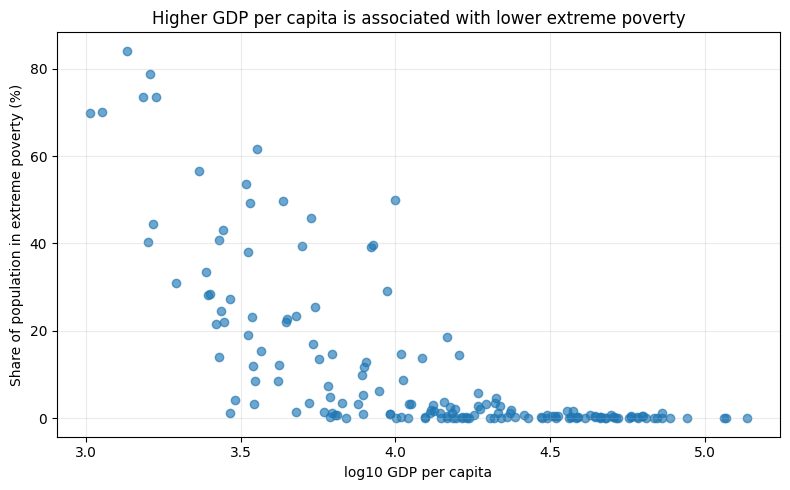

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    np.log10(latest_poverty_gdp[gdp_col]),
    latest_poverty_gdp[poverty_col],
    alpha=0.65,
)

ax.set_title("Higher GDP per capita is associated with lower extreme poverty")
ax.set_xlabel("log10 GDP per capita")
ax.set_ylabel("Share of population in extreme poverty (%)")
ax.grid(True, alpha=0.25)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_gdp_vs_extreme_poverty.png", dpi=160)
plt.show()

**Interpretation**

This chart supports the weak claim:

> Higher GDP per capita is associated with lower extreme poverty across countries.

It does **not** support the strong claim:

> Productivity growth, not taxation, fixes inequality.

The dependent variable above is poverty, not inequality.  
There is no tax variable in the plot.

## 2. Growth is not the same as distribution

Now we use Gini inequality data.

If GDP per capita automatically fixed inequality, rich countries would cluster tightly around low Gini values.  
They do not.

In [7]:
gdp_gini = (
    gini[["Entity", "Code", "Year", gini_col]]
    .merge(gdp[["Entity", "Code", "Year", gdp_col]], on=["Entity", "Code", "Year"], how="inner")
    .dropna()
)

gdp_gini = gdp_gini.loc[
    (gdp_gini[gdp_col] > 0) & (gdp_gini[gini_col] >= 0)
].copy()

latest_gini = latest_by_entity(gdp_gini, gini_col)
latest_gdp_for_gini = gdp_gini[["Entity", "Code", "Year", gdp_col]]

latest_gdp_gini = latest_gini.merge(
    latest_gdp_for_gini,
    on=["Entity", "Code", "Year"],
    how="left",
)

rho_gdp_gini = safe_spearman(np.log10(latest_gdp_gini[gdp_col]), latest_gdp_gini[gini_col])

high_income = latest_gdp_gini.loc[latest_gdp_gini[gdp_col] >= 30_000].copy()
gini_range_high_income = high_income[gini_col].max() - high_income[gini_col].min()

print(f"Countries with latest matched GDP/Gini observations: {latest_gdp_gini.shape[0]}")
print(f"Spearman correlation between log10(GDP per capita) and Gini: {rho_gdp_gini:.3f}")
print(f"Gini range among countries with GDP per capita >= 30,000: {gini_range_high_income:.2f} Gini points")

high_income.sort_values(gini_col, ascending=False).head(10)

Countries with latest matched GDP/Gini observations: 166
Spearman correlation between log10(GDP per capita) and Gini: -0.336
Gini range among countries with GDP per capita >= 30,000: 0.26 Gini points


,Entity,Code,Year,Gini coefficient,GDP per capita
117,Panama,PAN,2024,0.497335,36394.918
152,Turkey,TUR,2023,0.436758,35069.170
24,Chile,CHL,2024,0.430230,30182.787
158,United States,USA,2024,0.417625,75489.266
157,Uruguay,URY,2024,0.399841,32038.773
12,Bulgaria,BGR,2023,0.394705,33073.816
72,Israel,ISR,2022,0.383066,48098.188
127,Russia,RUS,2020,0.360682,36376.336
88,Lithuania,LTU,2023,0.359617,46159.707
125,Qatar,QAT,2017,0.351284,115064.836


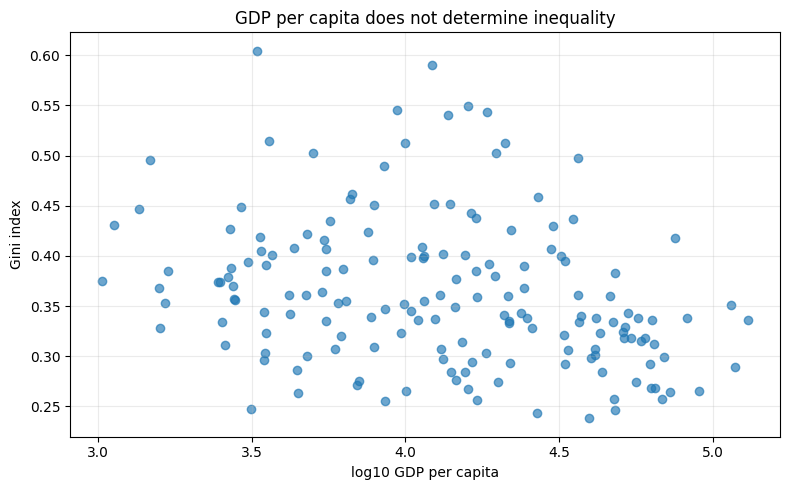

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    np.log10(latest_gdp_gini[gdp_col]),
    latest_gdp_gini[gini_col],
    alpha=0.65,
)

ax.set_title("GDP per capita does not determine inequality")
ax.set_xlabel("log10 GDP per capita")
ax.set_ylabel("Gini index")
ax.grid(True, alpha=0.25)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "02_gdp_vs_gini.png", dpi=160)
plt.show()

In [9]:
selected_countries = [
    "United States",
    "Denmark",
    "Sweden",
    "Norway",
    "Finland",
    "Portugal",
    "United Kingdom",
    "Germany",
    "France",
    "Ireland",
    "Chile",
]

comparison = (
    latest_gdp_gini.loc[latest_gdp_gini["Entity"].isin(selected_countries)]
    .sort_values(gdp_col, ascending=False)
    [["Entity", "Year", gdp_col, gini_col]]
)

comparison

,Entity,Year,GDP per capita,Gini coefficient
68,Ireland,2023,117862.125,0.289725
113,Norway,2023,90085.440,0.265308
158,United States,2024,75489.266,0.417625
38,Denmark,2023,69379.220,0.299248
36,Germany,2022,63676.086,0.336592
139,Sweden,2023,62662.766,0.292783
46,Finland,2023,56250.880,0.273998
48,France,2023,54296.723,0.318093
51,United Kingdom,2021,51004.426,0.324158
122,Portugal,2023,41768.254,0.338516


**Interpretation**

GDP per capita is an average. Gini is a distributional statistic.

Two countries can have similar levels of income per person and very different inequality.  
That means growth does not mechanically decide distribution.

So the original post commits a category error: it uses a poverty/GDP plot to make a claim about inequality and taxation.

## 3. Direct test of the tax-and-transfer system

The OECD variable used here is the percentage reduction in the Gini coefficient when income is measured **after taxes and benefits** rather than **before taxes and benefits**.

This is the direct counterexample to the phrase "not taxation".

Strictly speaking, this measures the **tax-benefit system**, not tax rates alone.  
That is the right object to study because taxes finance transfers and public redistribution.

In [10]:
latest_redistribution = latest_by_entity(redistribution, redistribution_col).copy()
latest_redistribution = latest_redistribution.rename(
    columns={redistribution_col: "gini_reduction_percent"}
)

summary_redistribution = latest_redistribution["gini_reduction_percent"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]
)

print(f"Countries/entities in redistribution dataset: {latest_redistribution.shape[0]}")
print(summary_redistribution)

latest_redistribution.sort_values("gini_reduction_percent", ascending=False).head(15)

Countries/entities in redistribution dataset: 45
count    45.000000
mean     30.046665
std      11.869140
min       2.671639
10%      12.678560
25%      23.191198
50%      33.101852
75%      38.056725
90%      42.316847
max      48.337510
Name: gini_reduction_percent, dtype: float64


,Entity,Code,Year,gini_reduction_percent
512,Slovakia,SVK,2023,48.337510
27,Belgium,BEL,2023,47.710392
218,Finland,FIN,2023,47.151280
158,Czechia,CZE,2023,43.472324
532,Slovenia,SVN,2023,42.417180
222,France,FRA,2023,42.166348
452,Poland,POL,2023,41.887990
21,Austria,AUT,2023,41.368305
313,Ireland,IRL,2023,41.187010
433,Norway,NOR,2022,39.489773


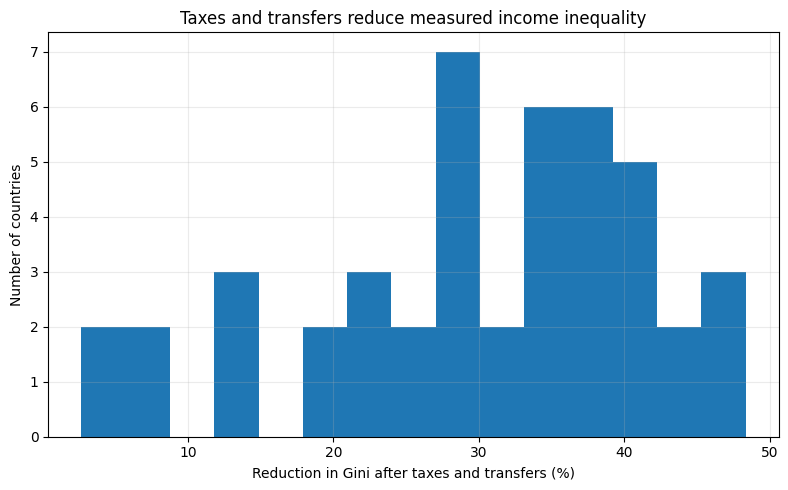

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

latest_redistribution["gini_reduction_percent"].dropna().plot(kind="hist", bins=15, ax=ax)

ax.set_title("Taxes and transfers reduce measured income inequality")
ax.set_xlabel("Reduction in Gini after taxes and transfers (%)")
ax.set_ylabel("Number of countries")
ax.grid(True, alpha=0.25)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "03_redistribution_histogram.png", dpi=160)
plt.show()

In [12]:
top_bottom = pd.concat(
    [
        latest_redistribution.sort_values("gini_reduction_percent", ascending=False).head(10).assign(group="largest reductions"),
        latest_redistribution.sort_values("gini_reduction_percent", ascending=True).head(10).assign(group="smallest reductions"),
    ],
    ignore_index=True,
)

top_bottom[["group", "Entity", "Year", "gini_reduction_percent"]]

,group,Entity,Year,gini_reduction_percent
0,largest reductions,Slovakia,2023,48.337510
1,largest reductions,Belgium,2023,47.710392
2,largest reductions,Finland,2023,47.151280
3,largest reductions,Czechia,2023,43.472324
4,largest reductions,Slovenia,2023,42.417180
5,largest reductions,France,2023,42.166348
6,largest reductions,Poland,2023,41.887990
7,largest reductions,Austria,2023,41.368305
8,largest reductions,Ireland,2023,41.187010
9,largest reductions,Norway,2022,39.489773


**Interpretation**

If the values are positive, then the tax-benefit system is reducing inequality.  
That directly contradicts the slogan.

A fair conclusion is not "growth does not matter".  
A fair conclusion is:

> Growth expands the income base. Redistribution changes the final distribution.

## 4. Optional: before-tax vs after-tax Gini from LIS

This cell tries to load the LIS before/after-tax Gini dataset from OWID.  
It is optional because the OECD reduction series above already measures the core effect.

LIS candidate columns:


 - Before tax
 - After tax


,Entity,Code,Year,Before tax,After tax,absolute_gini_reduction,relative_gini_reduction_percent
68,Belgium,BEL,2024,0.485046,0.243165,0.241881,49.867610
233,Czechia,CZE,2023,0.425769,0.243155,0.182614,42.890470
40,Austria,AUT,2023,0.494030,0.284358,0.209672,42.441121
608,Norway,NOR,2004,0.451502,0.260727,0.190775,42.253487
430,Ireland,IRL,2023,0.479100,0.276980,0.202120,42.187526
482,Italy,ITA,2022,0.552055,0.327933,0.224122,40.597776
878,Sweden,SWE,2023,0.462084,0.275645,0.186439,40.347497
249,Denmark,DNK,2022,0.476760,0.288110,0.188651,39.569331
783,Slovakia,SVK,2018,0.387025,0.236157,0.150868,38.981366
353,Germany,DEU,2022,0.509587,0.311946,0.197641,38.784603


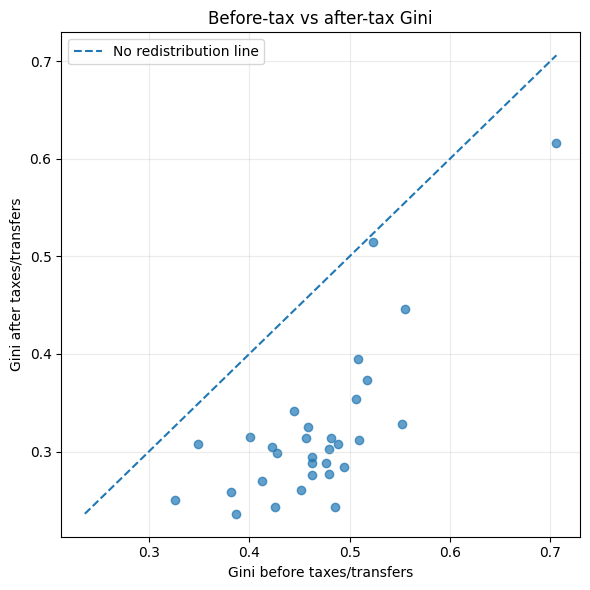

In [13]:
try:
    lis_raw = read_owid(OWID_DATASETS["before_after_lis"])
    lis_cols = value_columns(lis_raw)
    print("LIS candidate columns:")
    for col in lis_cols:
        print(" -", col)

    # Heuristic detection. If OWID changes names, inspect the printed list and adjust here.
    before_candidates = [c for c in lis_cols if "before" in c.lower() or "market" in c.lower()]
    after_candidates = [c for c in lis_cols if "after" in c.lower() or "disposable" in c.lower()]

    if before_candidates and after_candidates:
        before_col = before_candidates[0]
        after_col = after_candidates[0]

        lis = country_frame(lis_raw)
        lis_latest = (
            lis[["Entity", "Code", "Year", before_col, after_col]]
            .dropna()
            .sort_values(["Code", "Year"])
            .groupby(["Entity", "Code"], as_index=False)
            .tail(1)
            .copy()
        )
        lis_latest["absolute_gini_reduction"] = lis_latest[before_col] - lis_latest[after_col]
        lis_latest["relative_gini_reduction_percent"] = (
            lis_latest["absolute_gini_reduction"] / lis_latest[before_col] * 100
        )

        display(lis_latest.sort_values("relative_gini_reduction_percent", ascending=False).head(15))

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.scatter(lis_latest[before_col], lis_latest[after_col], alpha=0.7)

        lower = min(lis_latest[before_col].min(), lis_latest[after_col].min())
        upper = max(lis_latest[before_col].max(), lis_latest[after_col].max())
        ax.plot([lower, upper], [lower, upper], linestyle="--", label="No redistribution line")

        ax.set_title("Before-tax vs after-tax Gini")
        ax.set_xlabel("Gini before taxes/transfers")
        ax.set_ylabel("Gini after taxes/transfers")
        ax.legend()
        ax.grid(True, alpha=0.25)

        fig.tight_layout()
        fig.savefig(OUTPUT_DIR / "04_lis_before_after_gini.png", dpi=160)
        plt.show()
    else:
        print("Could not automatically detect before/after columns.")
except Exception as exc:
    print(f"Optional LIS section skipped: {exc}")

## 5. U.S. productivity vs typical worker earnings

The claim says productivity growth fixes distributional problems.  
A direct test is whether productivity growth reaches typical workers.

For the United States, we compare:

- **OPHNFB**: nonfarm business labour productivity, output per hour.
- **LES1252881600Q**: real median usual weekly earnings of full-time wage and salary workers.
- **COMPRNFB**: real hourly compensation for all workers.

The key series for the "typical worker" is the median earnings series.

In [14]:
fred = read_csv_cached(FRED_URL, DATA_DIR / "fred_productivity_wages.csv")
fred["observation_date"] = pd.to_datetime(fred["observation_date"])

for col in ["OPHNFB", "COMPRNFB", "LES1252881600Q"]:
    if col not in fred.columns:
        raise ValueError(f"Missing FRED column: {col}")
    fred[col] = pd.to_numeric(fred[col], errors="coerce")

fred_1979 = fred.loc[fred["observation_date"] >= "1979-01-01"].copy()
fred_1979 = fred_1979.dropna(subset=["OPHNFB", "LES1252881600Q"], how="all")

# Normalize each series to its first available value after 1979.
fred_1979["productivity_index"] = normalized_to_base(fred_1979["OPHNFB"])
fred_1979["all_worker_real_compensation_index"] = normalized_to_base(fred_1979["COMPRNFB"])
fred_1979["median_real_weekly_earnings_index"] = normalized_to_base(fred_1979["LES1252881600Q"])

fred_1979.tail()

,observation_date,OPHNFB,COMPRNFB,LES1252881600Q,productivity_index,all_worker_real_compensation_index,median_real_weekly_earnings_index
184,2025-01-01,116.187,109.465,373.0,234.177164,155.148466,111.343284
185,2025-04-01,117.385,109.337,376.0,236.591757,154.967047,112.238806
186,2025-07-01,118.884,110.158,376.0,239.613020,156.130678,112.238806
187,2025-10-01,119.350,110.486,NaN,240.552252,156.595564,NaN
188,2026-01-01,119.437,110.104,376.0,240.727603,156.054142,112.238806


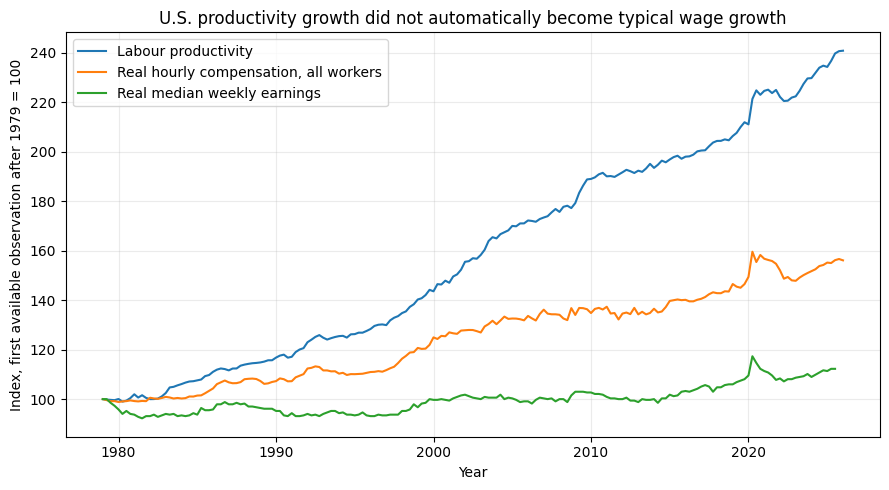

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(fred_1979["observation_date"], fred_1979["productivity_index"], label="Labour productivity")
ax.plot(fred_1979["observation_date"], fred_1979["all_worker_real_compensation_index"], label="Real hourly compensation, all workers")
ax.plot(fred_1979["observation_date"], fred_1979["median_real_weekly_earnings_index"], label="Real median weekly earnings")

ax.set_title("U.S. productivity growth did not automatically become typical wage growth")
ax.set_xlabel("Year")
ax.set_ylabel("Index, first available observation after 1979 = 100")
ax.legend()
ax.grid(True, alpha=0.25)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "05_us_productivity_vs_wages.png", dpi=160)
plt.show()

In [16]:
def growth_since_base(series: pd.Series) -> float:
    """Return percent growth from first to latest valid observation."""
    clean = pd.to_numeric(series, errors="coerce").dropna()
    if clean.empty:
        raise ValueError("No valid observations.")
    return float((clean.iloc[-1] / clean.iloc[0] - 1.0) * 100.0)


us_growth = pd.DataFrame(
    {
        "series": [
            "Labour productivity",
            "Real hourly compensation, all workers",
            "Real median weekly earnings",
        ],
        "growth_since_1979_percent": [
            growth_since_base(fred_1979["productivity_index"]),
            growth_since_base(fred_1979["all_worker_real_compensation_index"]),
            growth_since_base(fred_1979["median_real_weekly_earnings_index"]),
        ],
    }
)

us_growth

,series,growth_since_1979_percent
0,Labour productivity,140.727603
1,"Real hourly compensation, all workers",56.054142
2,Real median weekly earnings,12.238806


**Interpretation**

The U.S. evidence is not proof that productivity is irrelevant.  
It proves something more precise:

> Productivity growth does not automatically produce equal wage growth for the typical worker.

The distribution of productivity gains depends on institutions, bargaining power, tax policy, labour markets, and ownership.

## 6. Final verdict

The social-media claim is too strong.

### What the data supports

- GDP per capita is strongly associated with lower extreme poverty.
- Growth is important for escaping extreme material deprivation.

### What the data rejects

- The chart does not measure inequality.
- GDP per capita does not mechanically determine inequality.
- Taxes and transfers measurably reduce income inequality.
- Productivity gains do not automatically reach typical workers.

A defensible statement would be:

> Productivity growth is necessary for sustained living-standard improvements, but it is not sufficient to fix inequality.  
> Distribution is shaped by taxes, transfers, labour institutions, bargaining power, public services, market structure, and ownership.

In [17]:
verdict = {
    "poverty_gdp_spearman": rho_poverty_gdp,
    "gdp_gini_spearman": rho_gdp_gini,
    "high_income_gini_range": float(gini_range_high_income),
    "median_gini_reduction_after_tax_transfer_percent": float(
        latest_redistribution["gini_reduction_percent"].median()
    ),
    "us_growth_since_1979": us_growth.set_index("series")["growth_since_1979_percent"].to_dict(),
}

verdict_df = pd.DataFrame(
    [
        {"metric": key, "value": value}
        for key, value in verdict.items()
        if not isinstance(value, dict)
    ]
)

us_growth.to_csv(OUTPUT_DIR / "us_productivity_wage_growth_summary.csv", index=False)
verdict_df.to_csv(OUTPUT_DIR / "main_verdict_metrics.csv", index=False)
latest_redistribution.to_csv(OUTPUT_DIR / "latest_redistribution_effects.csv", index=False)

verdict

{'poverty_gdp_spearman': -0.7838595623965487,
 'gdp_gini_spearman': -0.33624886043903435,
 'high_income_gini_range': 0.25915828347206116,
 'median_gini_reduction_after_tax_transfer_percent': 33.101852,
 'us_growth_since_1979': {'Labour productivity': 140.72760253955457,
  'Real hourly compensation, all workers': 56.05414215859965,
  'Real median weekly earnings': 12.238805970149258}}

## A short rebuttal you can reuse

> The chart only shows that countries with higher GDP per capita tend to have lower extreme poverty.  
> It does not measure inequality and it does not test taxation.  
> OECD data directly measures the opposite: income inequality falls after taxes and transfers.  
> The U.S. also shows that productivity gains do not automatically become typical wage gains.  
> Growth creates capacity. Policy and power decide distribution.